In [6]:
import warnings
warnings.filterwarnings('ignore')


Fitting 3 folds for each of 10 candidates, totalling 30 fits


525/525 [==============================] - 2s 3ms/step
[CV] END batch_size=64, dropout_rate=0.5, epochs=50, layers=2, learning_rate=0.0001, neurons=32; total time= 1.5min
525/525 [==============================] - 1s 2ms/step
[CV] END batch_size=64, dropout_rate=0.5, epochs=50, layers=2, learning_rate=0.0001, neurons=32; total time= 1.5min
525/525 [==============================] - 2s 3ms/step
[CV] END batch_size=64, dropout_rate=0.5, epochs=50, layers=2, learning_rate=0.0001, neurons=32; total time= 1.5min
525/525 [==============================] - 1s 3ms/step
[CV] END batch_size=32, dropout_rate=0.3, epochs=100, layers=1, learning_rate=0.001, neurons=64; total time= 5.2min
525/525 [==============================] - 1s 2ms/step
[CV] END batch_size=32, dropout_rate=0.3, epochs=100, layers=1, learning_rate=0.001, neurons=64; total time= 5.4min
525/525 [==============================] - 1s 2ms/step
[CV] END batch_size=32, dr

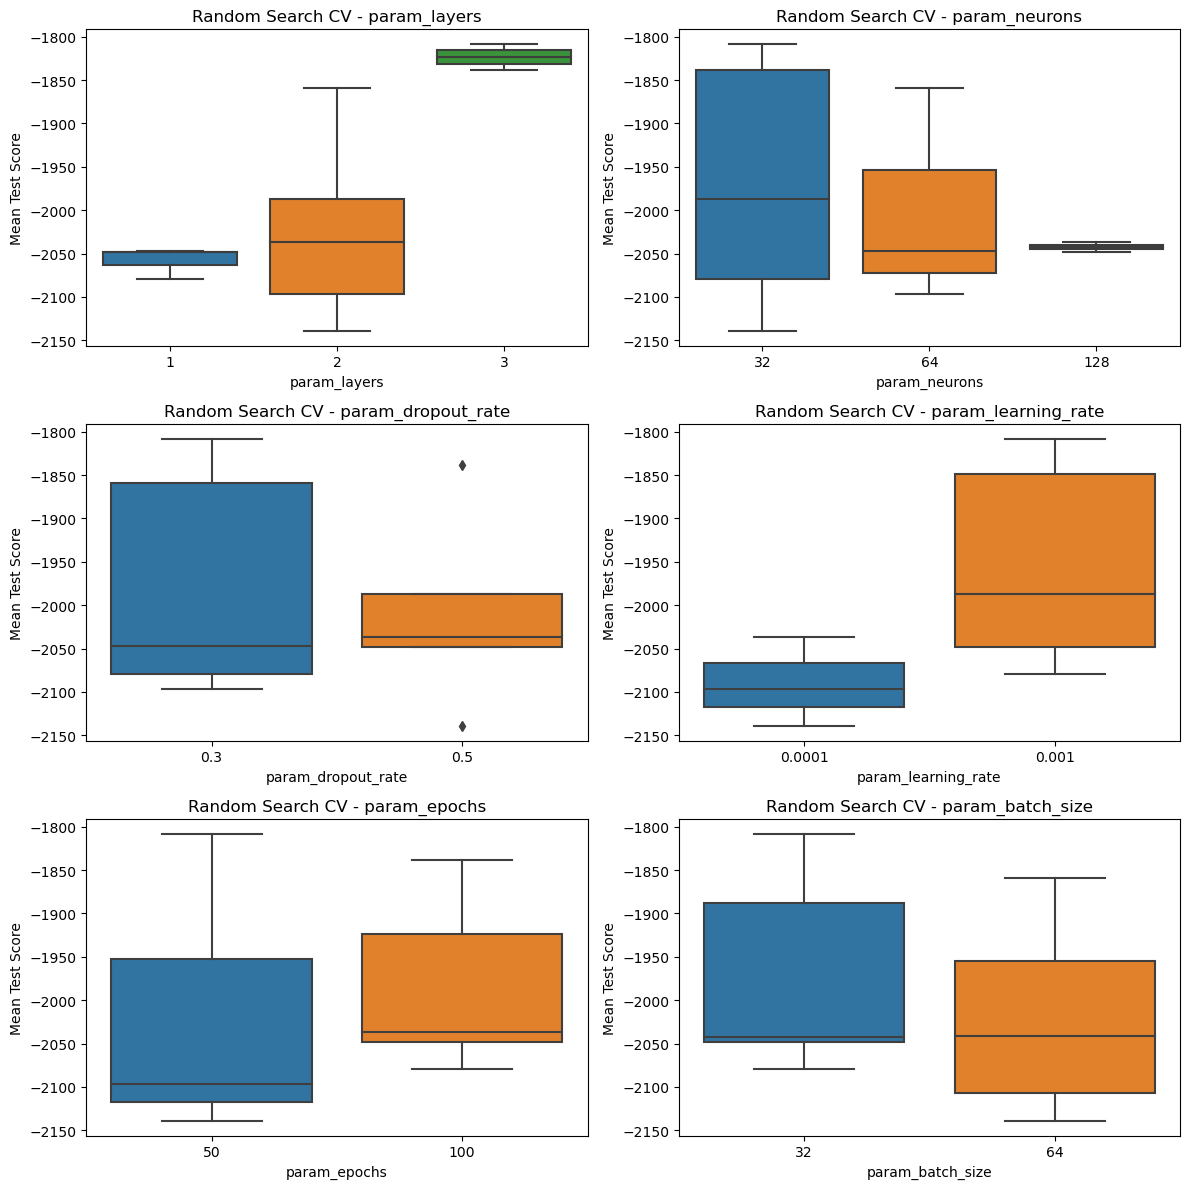

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from tensorflow import keras
from tensorflow.keras import layers, optimizers
from sklearn.base import BaseEstimator, RegressorMixin

# Assuming 'your_file.csv' is the name of your CSV file
training_folder = 'training'

# Read training data
training_files = [os.path.join(training_folder, file) for file in os.listdir(training_folder) if file.endswith('.csv')]
df_train = pd.concat([pd.read_csv(file) for file in training_files], ignore_index=True)

# Convert time string to seconds function
def time_to_seconds(time_str):
    # Split the time string by space
    time_parts = time_str.split()
    
    # Extract minutes and seconds
    minutes = float(time_parts[0][:-1])  # Remove 'm' and convert to float
    seconds = float(time_parts[1][:-1])  # Remove 's' and convert to float
    
    # Convert to seconds
    total_seconds = (minutes * 60) + seconds
    return total_seconds


# Preprocess 'OSD.flyTime' column
df_train['OSD.flyTime'] = df_train['OSD.flyTime'].apply(time_to_seconds)

# Selecting relevant features and target variables
input_features = ['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder']
output_targets = ['OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

# Splitting the dataset into features and target variables
X = df_train[input_features]
y = df_train[output_targets]

# Handling missing values in input features using SimpleImputer
imputer = SimpleImputer(strategy='mean')  
X_imputed = imputer.fit_transform(X)

# Normalize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Define a wrapper class for KerasRegressor
class KerasRegressorWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, layers=1, neurons=64, dropout_rate=0.3, learning_rate=0.001, epochs=100, batch_size=32):
        self.layers = layers
        self.neurons = neurons
        self.dropout_rate = dropout_rate
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.model = None

    def create_model(self):
        model = keras.Sequential()
        model.add(layers.Dense(self.neurons, activation='relu', input_shape=(X_train.shape[1],)))
        model.add(layers.Dropout(self.dropout_rate))
        for _ in range(self.layers - 1):
            model.add(layers.Dense(self.neurons, activation='relu'))
            model.add(layers.Dropout(self.dropout_rate))
        model.add(layers.Dense(len(output_targets)))
        optimizer = optimizers.Adam(learning_rate=self.learning_rate)
        model.compile(optimizer=optimizer, loss='mean_squared_error')
        return model

    def fit(self, X, y):
        self.model = self.create_model()
        self.model.fit(X, y, epochs=self.epochs, batch_size=self.batch_size, verbose=0)
        return self

    def predict(self, X):
        return self.model.predict(X)

# Define hyperparameters to tune
param_dist = {
    'layers': [1, 2, 3], # number of hidden layers
    'neurons': [32, 64, 128], # number of neurons per layer
    'dropout_rate': [0.3, 0.5], # dropout rate
    'learning_rate': [0.001, 0.0001], # learning rate
    'epochs': [50, 100], # number of training epochs
    'batch_size': [32, 64] # batch size
}

# Create KerasRegressor wrapper
model = KerasRegressorWrapper()

# Perform random search
random_search = RandomizedSearchCV(estimator=model, param_distributions=param_dist, n_iter=10, scoring='neg_mean_squared_error', cv=3, verbose=2, random_state=42, n_jobs=1)

random_search.fit(X_train, y_train)

# Print best parameters and best score
print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

# Extract results from random search
results = pd.DataFrame(random_search.cv_results_)

# Define hyperparameters to plot
hyperparameters = ['param_layers', 'param_neurons', 'param_dropout_rate', 'param_learning_rate',
                   'param_epochs', 'param_batch_size']

# Plot random search results
plt.figure(figsize=(12, 12))
for i, param in enumerate(hyperparameters):
    plt.subplot(3, 2, i+1)
    sns.boxplot(x=param, y='mean_test_score', data=results, ax=plt.gca())
    plt.title(f'Random Search CV - {param}')
    plt.xlabel(param)
    plt.ylabel('Mean Test Score')
plt.tight_layout()
plt.show()


In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from tensorflow import keras
from tensorflow.keras import layers

# Assuming 'your_file.csv' is the name of your CSV file
training_folder = 'training'

# Read training data
training_files = [os.path.join(training_folder, file) for file in os.listdir(training_folder) if file.endswith('.csv')]
df_train = pd.concat([pd.read_csv(file) for file in training_files], ignore_index=True)

# Convert time string to seconds function
def time_to_seconds(time_str):
    # Split the time string by space
    time_parts = time_str.split()
    
    # Extract minutes and seconds
    minutes = float(time_parts[0][:-1])  # Remove 'm' and convert to float
    seconds = float(time_parts[1][:-1])  # Remove 's' and convert to float
    
    # Convert to seconds
    total_seconds = (minutes * 60) + seconds
    return total_seconds


# Preprocess 'OSD.flyTime' column
df_train['OSD.flyTime'] = df_train['OSD.flyTime'].apply(time_to_seconds)

# Selecting relevant features and target variables
input_features = ['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder']
output_targets = ['OSD.longitude', 'OSD.latitude', 'OSD.altitude [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

# Splitting the dataset into features and target variables
X = df_train[input_features]
y = df_train[output_targets]

# Handling missing values in input features using SimpleImputer
imputer = SimpleImputer(strategy='mean')  
X_imputed = imputer.fit_transform(X)

# Normalize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Build the model using best parameters
model = keras.Sequential()
model.add(layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
model.add(layers.Dropout(0.3))
for _ in range(3 - 1):
    model.add(layers.Dense(32, activation='relu'))
    model.add(layers.Dropout(0.3))
model.add(layers.Dense(len(output_targets)))

# Compile the model
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

# Evaluate the model
mse = model.evaluate(X_test, y_test, verbose=0)
print("Test Mean Squared Error:", mse)




Epoch 1/50

1360/1360 [==============================] - 5s 3ms/step - loss: 2524.3914 - val_loss: 2166.6919
Epoch 2/50
1360/1360 [==============================] - 4s 3ms/step - loss: 2271.9663 - val_loss: 2134.1265
Epoch 3/50
1360/1360 [==============================] - 4s 3ms/step - loss: 2239.8176 - val_loss: 2125.3418
Epoch 4/50
1360/1360 [==============================] - 4s 3ms/step - loss: 2215.4487 - val_loss: 2113.7585
Epoch 5/50
1360/1360 [==============================] - 4s 3ms/step - loss: 2204.6372 - val_loss: 2107.5022
Epoch 6/50
1360/1360 [==============================] - 4s 3ms/step - loss: 2189.7896 - val_loss: 2095.1145
Epoch 7/50
1360/1360 [==============================] - 4s 3ms/step - loss: 2181.8755 - val_loss: 2094.1738
Epoch 8/50
1360/1360 [==============================] - 4s 3ms/step - loss: 2163.9319 - val_loss: 2075.0647
Epoch 9/50
1360/1360 [==============================] - 4s 3ms/step - loss: 2157.7747 - val_loss: 2069.2329
Epoch 10/50
1360/1360 [==

In [3]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

test_folder = 'testing'
test_files = [os.path.join(test_folder, file) for file in os.listdir(test_folder) if file.endswith('.csv')]
df_test_custom = pd.concat([pd.read_csv(file) for file in test_files], ignore_index=True)

# Preprocess 'OSD.flyTime' column in the test dataset
df_test_custom['OSD.flyTime'] = df_test_custom['OSD.flyTime'].apply(time_to_seconds)

# Handling missing values in input features using SimpleImputer
X_test_custom_imputed = imputer.transform(df_test_custom[input_features])

# Normalize the custom test data
X_test_custom_scaled = scaler.transform(X_test_custom_imputed)

# Make predictions on the custom test set
y_pred_custom = model.predict(X_test_custom_scaled)

# Calculate and display accuracy metrics for each target variable on the custom test set
for i, target_variable in enumerate(output_targets):
    mse_custom = mean_squared_error(df_test_custom[target_variable], y_pred_custom[:, i])
    r2_custom = r2_score(df_test_custom[target_variable], y_pred_custom[:, i])
    mae_custom = mean_absolute_error(df_test_custom[target_variable], y_pred_custom[:, i])
    variance_explained_custom = 100 * (1 - mse_custom / np.var(df_test_custom[target_variable]))
    
    print(f'{target_variable} - Mean Squared Error: {mse_custom:.2f}, R-squared: {r2_custom:.2%}, Mean Absolute Error: {mae_custom:.2f}, Variance Explained: {variance_explained_custom:.2f}%')


# Create a 3D plot for the actual drone path on custom test set
fig_actual_custom = plt.figure(figsize=(12, 8))
ax_actual_custom = fig_actual_custom.add_subplot(111, projection='3d')
ax_actual_custom.scatter(df_test_custom['OSD.longitude'], df_test_custom['OSD.latitude'], df_test_custom['OSD.altitude [ft]'], c='blue', marker='o', label='Actual Path')
ax_actual_custom.set_xlabel('Longitude')
ax_actual_custom.set_ylabel('Latitude')
ax_actual_custom.set_zlabel('Altitude (ft)')
ax_actual_custom.set_title('Actual Drone Path on Custom Test Set')
ax_actual_custom.legend()

# Create a 3D plot for the predicted drone path on custom test set
fig_predicted_custom = plt.figure(figsize=(12, 8))
ax_predicted_custom = fig_predicted_custom.add_subplot(111, projection='3d')
ax_predicted_custom.scatter(y_pred_custom[:, 0], y_pred_custom[:, 1], y_pred_custom[:, 2], c='red', marker='x', label='Predicted Path')
ax_predicted_custom.set_xlabel('Longitude')
ax_predicted_custom.set_ylabel('Latitude')
ax_predicted_custom.set_zlabel('Altitude (ft)')
ax_predicted_custom.set_title('Predicted Drone Path on Custom Test Set')
ax_predicted_custom.legend()

# Show the actual and predicted path plots on the custom test set
plt.show()



NameError: name 'os' is not defined